# **Instalado o modelo**

In [2]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 3.7 MB/s eta 0:00:00


In [1]:
from pmdarima.arima import auto_arima

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm
from  matplotlib.pylab import rcParams
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
rcParams['figure.figsize'] =15,7

## **Série Air Passengers**

In [4]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Carregar AirPassengers
df_air = sm.datasets.get_rdataset("AirPassengers").data
serie_ar_passengers = pd.Series(df_air['value'].values, index=pd.date_range('1949-01-01', periods=len(df_air), freq='MS'))

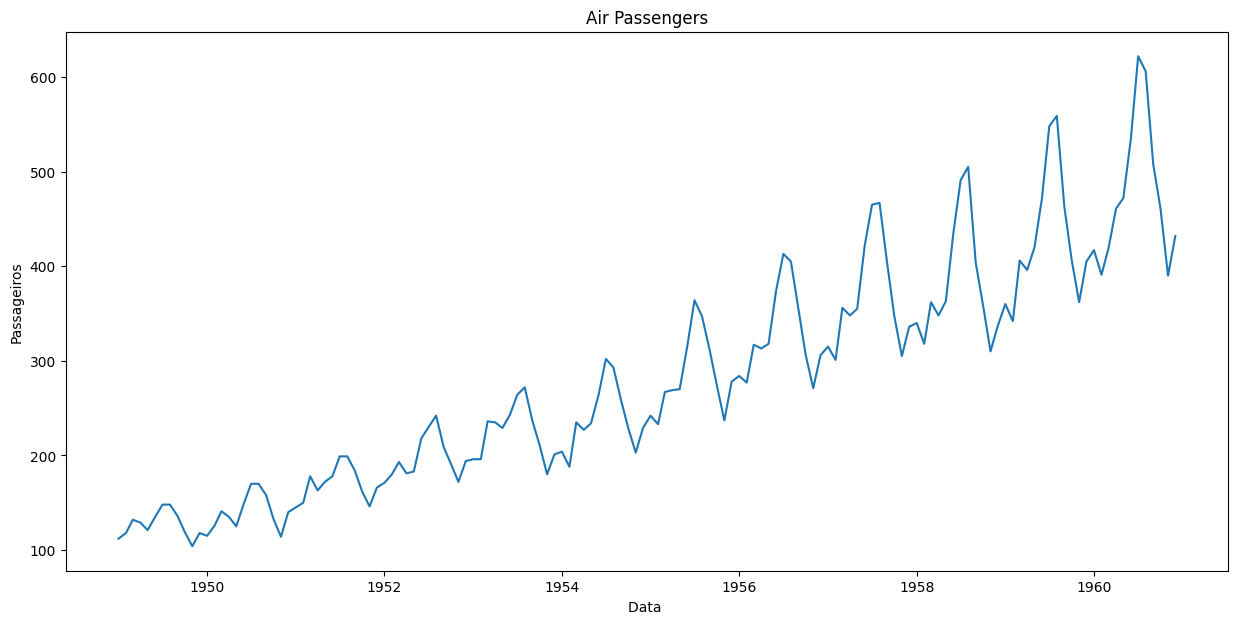

In [5]:
plt.plot(serie_ar_passengers)
plt.title('Air Passengers')
plt.xlabel('Data ')
plt.ylabel('Passageiros')
plt.show()

## **Estudo da Série temporal**


Nesta seção será realizdo o estudo da série temporal, onde serão avaliados:

* Decomposição
* Normalidade da série.
* Teste de Shapiro-Wilk
* Grafico QQ_plot
* Histograma
* Estacionariadade (Teste KPSS)
* Funções de auto correlação (ACF e PACF)

## **Realizamos este estudos no exercício anterior.**

## **Modelo AUTO ARIMA**


Os parâmetros principais de um modelo Auto-ARIMA determinam a estrutura de autocorrelação, tendência e sazonalidade de uma série temporal de forma automatizada.


### **Parâmetros Principais (Não Sazonais)**

* **p (Ordem Autorregressiva - AR):** Quantidade de valores passados (lags) usados para prever o valor atual.
* **d (Grau de Diferenciação - I):** Número de vezes que a série precisa ser subtraída para se tornar estacionária (sem tendência).
* **q (Ordem de Média Móvel - MA):** Tamanho da janela de erros passados considerada no cálculo.



### **Parâmetros Sazonais (SARIMA)**

Se a opção sazonal estiver ativa, o algoritmo também otimiza:
* **P:** Ordem autorregressiva sazonal.
* **D:** Grau de diferenciação sazonal.
* **Q:** Ordem de média móvel sazonal.
* **m:** Período da sazonalidade (ex: 12 para dados mensais)

###  **Parâmetros de Busca do Algoritmo**

* **start_p, max_p**: Valores inicial e máximo para o parâmetro p.

* **start_q, max_q:** Valores inicial e máximo para o parâmetro q.
* **stepwise:** Define se a busca será rápida por etapas (True) ou exaustiva testando todas as combinações (False).

# **Implementação do modelo AUTO-ARIMA**
* Definição do modelo
* Estudo do resíduo
* Aplicação do modelo.

### **Documentação auto_arima**

https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.arima.auto_arima.html

## **Definição do modelo SARIMA**

In [6]:
modelo_auto_arima = auto_arima(serie_ar_passengers, seasonal=True, stepwise=False,start_p=0, max_p=5, start_q=0,
                               max_q=5,start_Q=0, max_Q=5,start_P=0, max_P=5, m=12, trace=True)

 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.06 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=1030.752, Time=0.08 sec
 ARIMA(0,1,0)(0,1,2)[12]             : AIC=1032.276, Time=0.24 sec
 ARIMA(0,1,0)(0,1,3)[12]             : AIC=1033.978, Time=0.58 sec
 ARIMA(0,1,0)(0,1,4)[12]             : AIC=1035.395, Time=1.01 sec
 ARIMA(0,1,0)(0,1,5)[12]             : AIC=inf, Time=6.48 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=1030.408, Time=0.05 sec
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=1032.128, Time=0.15 sec
 ARIMA(0,1,0)(1,1,2)[12]             : AIC=1034.096, Time=0.43 sec
 ARIMA(0,1,0)(1,1,3)[12]             : AIC=1035.935, Time=1.98 sec
 ARIMA(0,1,0)(1,1,4)[12]             : AIC=inf, Time=6.00 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=1032.120, Time=0.19 sec
 ARIMA(0,1,0)(2,1,1)[12]             : AIC=inf, Time=1.17 sec
 ARIMA(0,1,0)(2,1,2)[12]             : AIC=inf, Time=1.62 sec
 ARIMA(0,1,0)(2,1,3)[12]             : AIC=inf, Time=4.05 sec
 ARIMA(0,1,0)(3,1,0)

In [7]:
print(modelo_auto_arima.summary())

                                        SARIMAX Results                                        
Dep. Variable:                                       y   No. Observations:                  144
Model:             SARIMAX(0, 1, 1)x(1, 1, [1, 2], 12)   Log Likelihood                -501.495
Date:                                 Fri, 18 Sep 2026   AIC                           1012.991
Time:                                         11:02:17   BIC                           1027.367
Sample:                                     01-01-1949   HQIC                          1018.832
                                          - 12-01-1960                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4279      0.063     -6.757      0.000      -0.552      -0

In [10]:
modelo_auto_arima_result = modelo_auto_arima.fit(serie_ar_passengers)

## **Estudo do resíduo**

In [13]:
residuos_modelo_auto_arima = modelo_auto_arima_result.resid

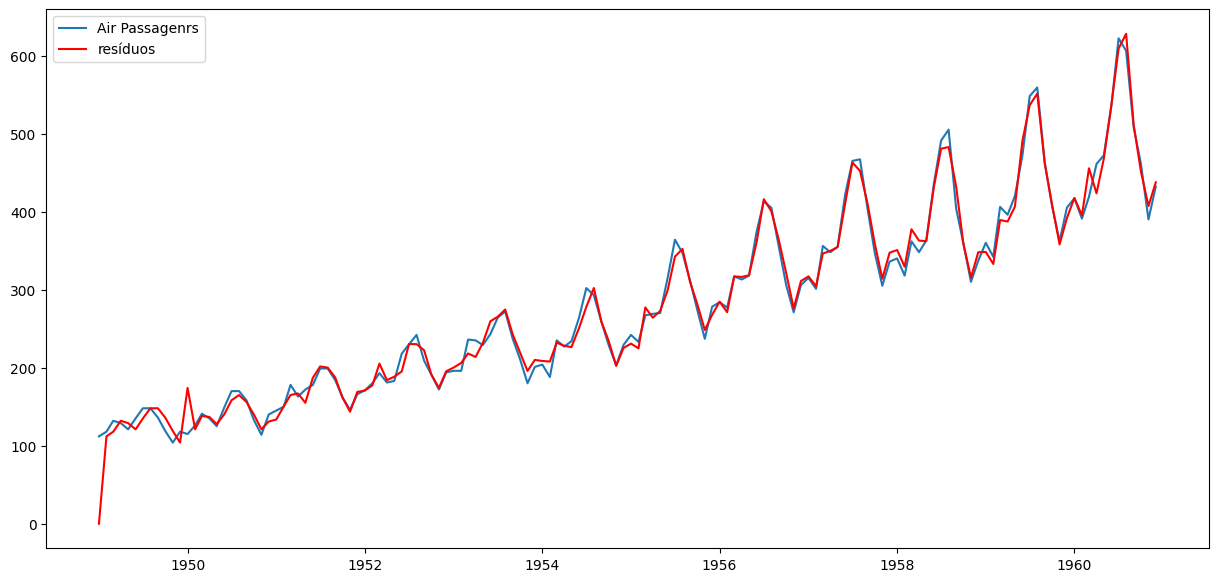

In [15]:
plt.plot(serie_ar_passengers, label  ="Air Passagenrs")
plt.plot(serie_ar_passengers-residuos_modelo_auto_arima(), color ='red', label ="resíduos")
plt.legend(loc = 'best')
plt.show()

###  **Normalidade do resíduo**

### **QQ_plot resíduo**

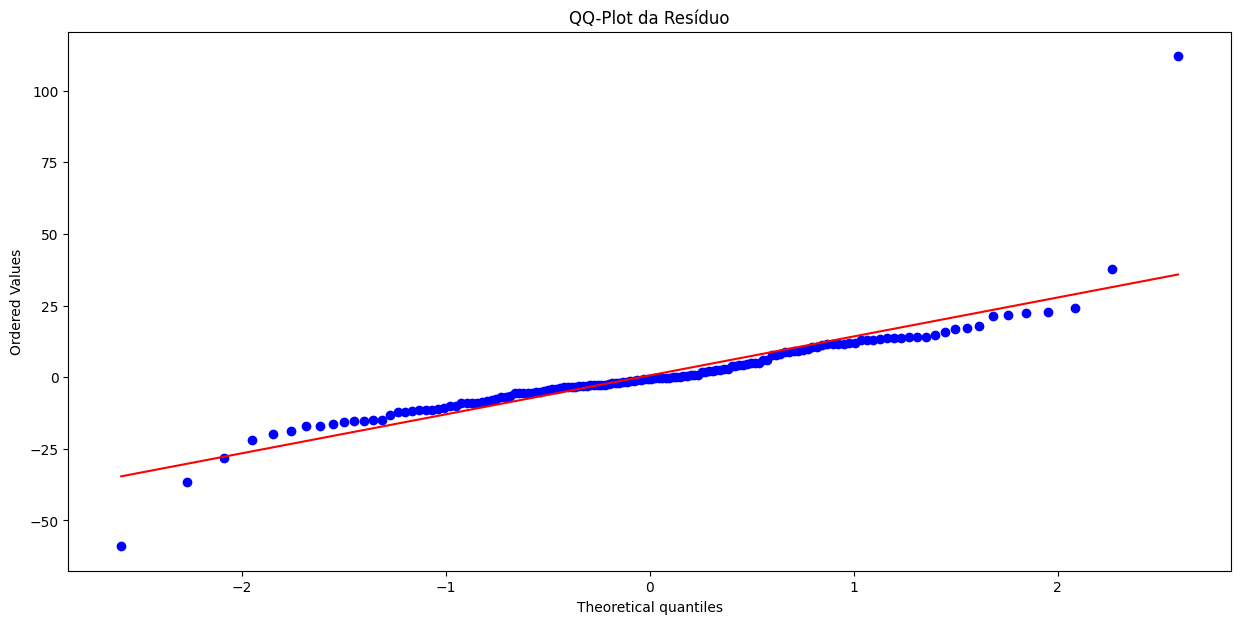

In [16]:
import scipy.stats as stats
stats.probplot(residuos_modelo_auto_arima(), dist='norm', plot=plt)
plt.title('QQ-Plot da Resíduo')
plt.show()

In [17]:
e,p_valor =stats.shapiro(residuos_modelo_auto_arima())
print('Estatistica de teste = %.3f, p-valor = %.3f' % (e,p_valor))

Estatistica de teste = 0.799, p-valor = 0.000


In [18]:
if p_valor >= 0.05:
  print('Não há evidências para rejeitar a hipótese nula. Os dados seguem uma distribuição normal.')
else:
  print('Rejeita-se a hipótese nula. Os dados não seguem uma distribuição normal.')

Rejeita-se a hipótese nula. Os dados não seguem uma distribuição normal.


### **Histograma resíduo**

## **Autocorrelacao Resíduos**

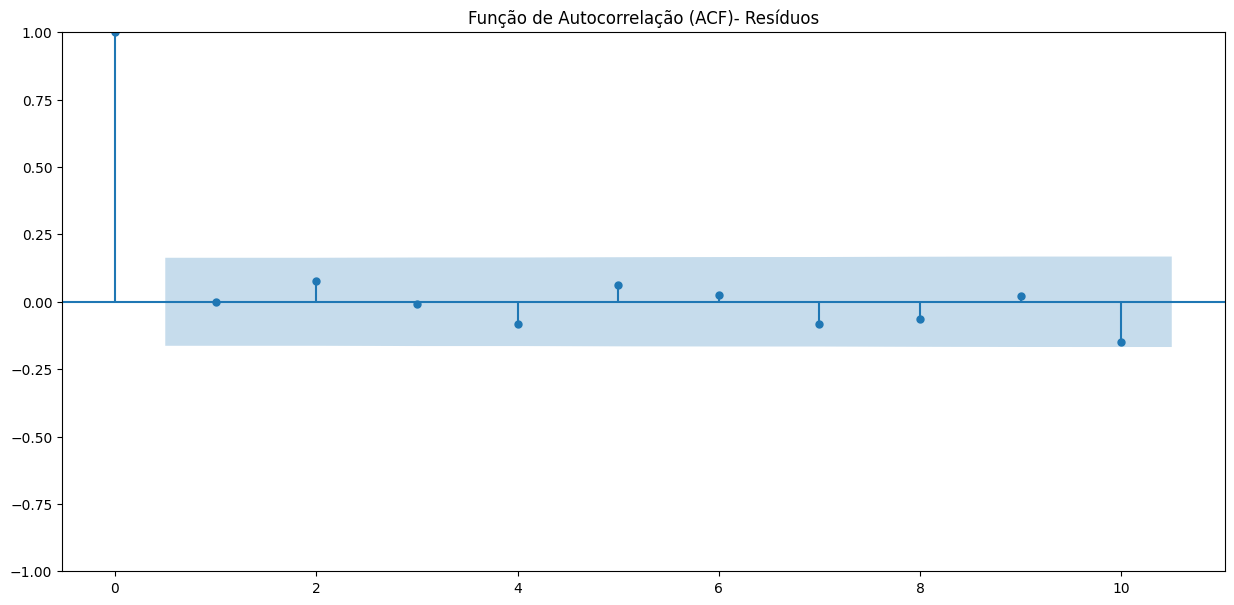

In [20]:
plot_acf(residuos_modelo_auto_arima(),lags=10, color='#1f77b4', title='Função de Autocorrelação (ACF)- Resíduos')
plt.show()

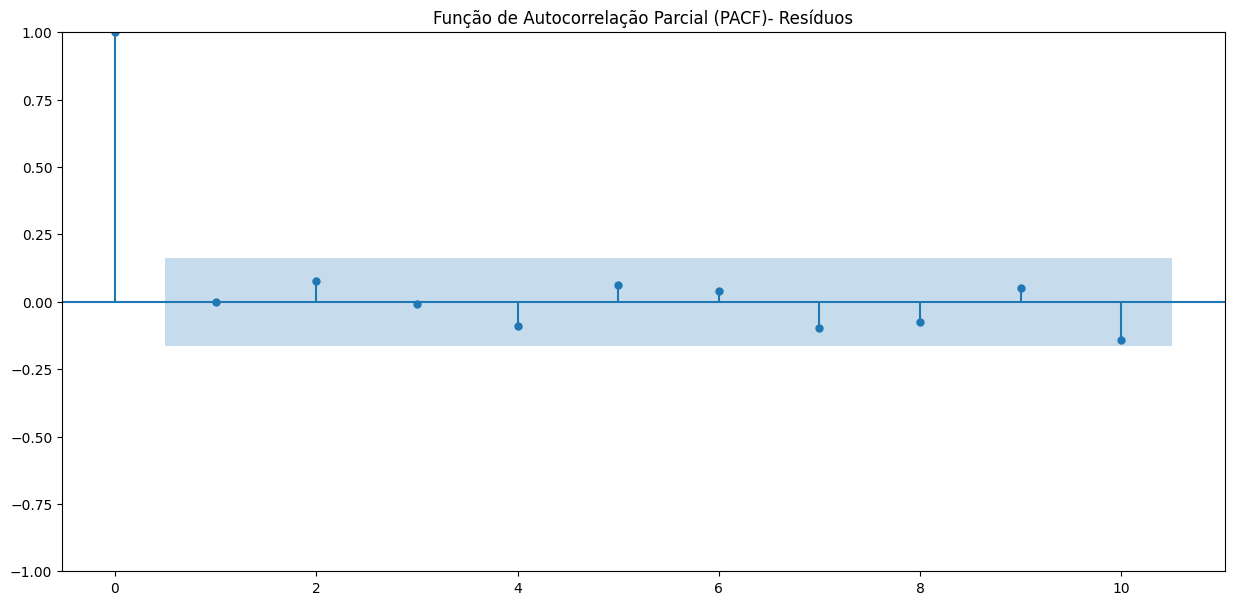

In [21]:
plot_pacf(residuos_modelo_auto_arima(),lags=10, color='#1f77b4', title='Função de Autocorrelação Parcial (PACF)- Resíduos')
plt.show()

# **Aplicando o modelo**

In [24]:
previsao_modelo_auto_arima = modelo_auto_arima_result.predict(n_periods=36)

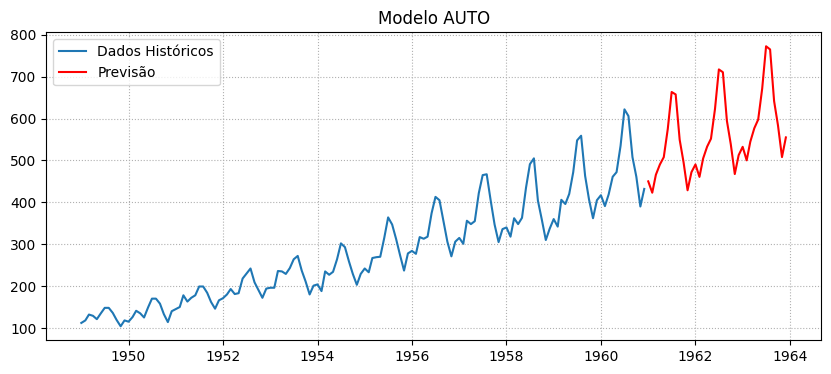

In [25]:
plt.figure(figsize=(10, 4))
plt.plot(serie_ar_passengers, label='Dados Históricos')
plt.plot(previsao_modelo_auto_arima, color='red', label='Previsão')
plt.title('Modelo AUTO')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

In [28]:
previsao, intervalos = modelo_auto_arima_result.predict(
    n_periods=36,
    return_conf_int=True,
    alpha=0.05  # IC de 95%
)

In [31]:
import pandas as pd

df_previsao = pd.DataFrame({
    "previsao": previsao,
    "lower_95": intervalos[:, 0],
    "upper_95": intervalos[:, 1]
})

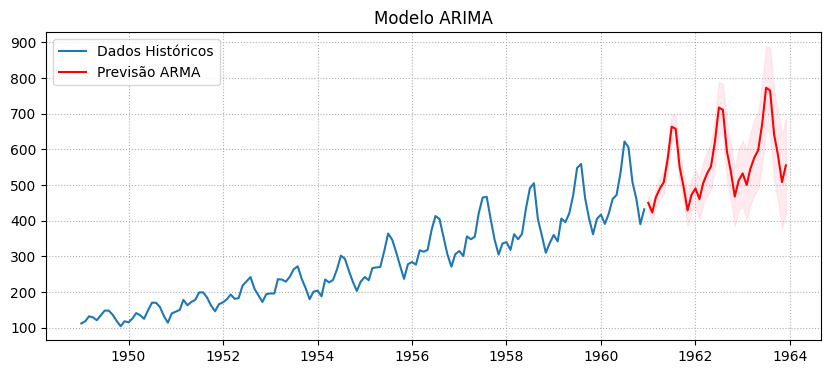

In [34]:
plt.figure(figsize=(10, 4))
plt.plot(serie_ar_passengers, label='Dados Históricos')
plt.plot(df_previsao['previsao'], color='red', label='Previsão ARMA')
plt.fill_between(previsao.index,df_previsao["lower_95"], df_previsao["upper_95"], color='pink', alpha=0.3)
plt.title('Modelo ARIMA')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()